# Analiza wykorzystania pamięci RAM dla VGG16 i AlexNet

Celem eksperymentu jest sprawdzenie, jak zmienia się zużycie pamięci RAM podczas pracy z modelami VGG16 oraz AlexNet.

Eksperyment mierzy pamięć dla kilku etapów:

1. wczytanie zbioru CIFAR-10,
2. utworzenie modelu,
3. trening modelu,
4. ewaluacja modelu na zbiorze testowym.

In [1]:
from pathlib import Path
import os
import time
import gc
import threading

import pandas as pd
import matplotlib.pyplot as plt

import torch
import psutil
import adom_library as adom

adom.show_device()

RESULTS_DIR = Path("experiments_results")
RESULTS_DIR.mkdir(exist_ok=True)

RESULTS_PATH = RESULTS_DIR / "results_ram_analysis.csv" # "results_vgg16_ram_analysis.csv"
SUMMARY_RESULTS_PATH = RESULTS_DIR / "summary_ram_analysis.csv"

cuda


## Parametry eksperymentu

W `MODEL_TYPES` można zostawić oba modele albo uruchomić tylko jeden, np. `MODEL_TYPES = ["AlexNet"]`.


In [2]:
MODEL_TYPES = ["VGG16", "AlexNet"]

EPOCHS = 1
BATCH_SIZE = 64
DROPOUT_VALUE = None

## Funkcje pomocnicze do pomiaru RAM

Funkcja `measure_memory_usage(...)` uruchamia wskazaną operację i w tle próbuje mierzyć maksymalne zużycie pamięci RAM procesu Pythona. Zwraca wynik operacji oraz słownik z pomiarem pamięci.

Dodatkowo, jeżeli dostępna jest karta CUDA, zapisywane są także przybliżone wartości wykorzystania pamięci GPU.


In [3]:
process = psutil.Process(os.getpid())


def get_ram_mb():
    return process.memory_info().rss / (1024 ** 2)


def get_gpu_memory_mb():
    if not torch.cuda.is_available():
        return {
            "gpu_allocated_mb": None,
            "gpu_reserved_mb": None,
            "gpu_peak_allocated_mb": None,
            "gpu_peak_reserved_mb": None,
        }

    return {
        "gpu_allocated_mb": torch.cuda.memory_allocated() / (1024 ** 2),
        "gpu_reserved_mb": torch.cuda.memory_reserved() / (1024 ** 2),
        "gpu_peak_allocated_mb": torch.cuda.max_memory_allocated() / (1024 ** 2),
        "gpu_peak_reserved_mb": torch.cuda.max_memory_reserved() / (1024 ** 2),
    }


def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def measure_memory_usage(stage_name, operation, model_type=None, sample_interval=0.05):
    cleanup_memory()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    ram_before = get_ram_mb()
    peak_ram = ram_before
    stop_sampling = False

    def sampler():
        nonlocal peak_ram, stop_sampling
        while not stop_sampling:
            current_ram = get_ram_mb()
            if current_ram > peak_ram:
                peak_ram = current_ram
            time.sleep(sample_interval)

    thread = threading.Thread(target=sampler)
    thread.daemon = True

    start_time = time.time()
    thread.start()

    result = None
    error = None

    try:
        result = operation()
    except Exception as exc:
        error = exc
    finally:
        stop_sampling = True
        thread.join()

    elapsed_time = time.time() - start_time
    ram_after = get_ram_mb()
    gpu = get_gpu_memory_mb()

    metrics = {
        "model_type": model_type,
        "stage": stage_name,
        "ram_before_mb": ram_before,
        "ram_after_mb": ram_after,
        "ram_peak_mb": peak_ram,
        "ram_peak_increase_mb": peak_ram - ram_before,
        "time_seconds": elapsed_time,
        **gpu,
    }

    if error is not None:
        raise error

    return result, metrics


def print_metrics(metrics):
    if metrics.get("model_type"):
        print(f"Model: {metrics['model_type']}")

    print(f"Etap: {metrics['stage']}")
    print(f"RAM przed: {metrics['ram_before_mb']:.2f} MB")
    print(f"RAM po: {metrics['ram_after_mb']:.2f} MB")
    print(f"RAM peak: {metrics['ram_peak_mb']:.2f} MB")
    print(f"Wzrost peak RAM: {metrics['ram_peak_increase_mb']:.2f} MB")
    print(f"Czas: {metrics['time_seconds']:.2f} s")

    if metrics["gpu_peak_allocated_mb"] is not None:
        print(f"GPU peak allocated: {metrics['gpu_peak_allocated_mb']:.2f} MB")
        print(f"GPU peak reserved: {metrics['gpu_peak_reserved_mb']:.2f} MB")

## Pomiar początkowy


In [4]:
initial_metrics = {
    "model_type": None,
    "stage": "Stan początkowy",
    "ram_before_mb": get_ram_mb(),
    "ram_after_mb": get_ram_mb(),
    "ram_peak_mb": get_ram_mb(),
    "ram_peak_increase_mb": 0.0,
    "time_seconds": 0.0,
    **get_gpu_memory_mb(),
}

measurements = [initial_metrics]
model_summaries = []
print_metrics(initial_metrics)

Etap: Stan początkowy
RAM przed: 528.16 MB
RAM po: 528.16 MB
RAM peak: 528.16 MB
Wzrost peak RAM: 0.00 MB
Czas: 0.00 s
GPU peak allocated: 0.00 MB
GPU peak reserved: 0.00 MB


## Wczytanie CIFAR-10

Zbiór danych jest wczytywany raz i potem używany dla obu architektur.

In [5]:
def load_cifar10():
    train_dataset = adom.get_CIFAR10_dataset(train_dataset=True)
    test_dataset = adom.get_CIFAR10_dataset(train_dataset=False)
    return train_dataset, test_dataset


(train_dataset, test_dataset), metrics = measure_memory_usage(
    "Wczytanie CIFAR-10",
    load_cifar10,
    model_type=None,
)

measurements.append(metrics)
print_metrics(metrics)

classes = train_dataset.classes
print("\nLiczba klas:", len(classes))
print("Klasy:", classes)
print("Liczba obrazów treningowych:", len(train_dataset))
print("Liczba obrazów testowych:", len(test_dataset))

Files already downloaded and verified


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Etap: Wczytanie CIFAR-10
RAM przed: 528.57 MB
RAM po: 706.79 MB
RAM peak: 706.79 MB
Wzrost peak RAM: 178.23 MB
Czas: 1.32 s
GPU peak allocated: 0.00 MB
GPU peak reserved: 0.00 MB

Liczba klas: 10
Klasy: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Liczba obrazów treningowych: 50000
Liczba obrazów testowych: 10000


## Funkcje dla pojedynczego modelu

In [6]:
def create_model(model_type):
    model = adom.get_model_without_weights(
        num_classes=len(classes),
        model_type=model_type,
    )
    model = adom.set_dropout(model, model_type, DROPOUT_VALUE)
    return model


def train_model(model_type):
    return adom.train_new_model(
        train_dataset=train_dataset,
        model_type=model_type,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        dropout_value=DROPOUT_VALUE,
    )


def evaluate_model_on_test(model):
    return adom.evaluate_model_on_dataset(
        model=model,
        dataset=test_dataset,
        classes=classes,
    )

## Analiza RAM dla VGG16 i AlexNet

Pętla wykonuje kolejno: utworzenie modelu, trening i ewaluację dla każdej architektury. Po zakończeniu pracy z danym modelem obiekt jest usuwany, żeby następny model startował z możliwie czystszego stanu pamięci.

Po pomiarze tworzenia modelu usuwamy tymczasowy model. Właściwy model zostanie utworzony jeszcze raz przez `adom.train_new_model(...)`, zgodnie ze sposobem działania biblioteki.


In [7]:
for model_type in MODEL_TYPES:
    print("=" * 60)
    print(f"Analiza modelu: {model_type}")
    print("=" * 60)

    # === Pomiar utworzenia modelu ===

    model_for_memory_check, metrics = measure_memory_usage(
        f"Utworzenie modelu {model_type}",
        lambda model_type=model_type: create_model(model_type),
        model_type=model_type,
    )

    measurements.append(metrics)
    print_metrics(metrics)
    trainable_params = adom.count_model_params(model_for_memory_check)
    print("\nLiczba trenowalnych parametrów:", trainable_params)

    del model_for_memory_check
    cleanup_memory()
    print(f"RAM po usunięciu modelu tymczasowego: {get_ram_mb():.2f} MB")

    # === Pomiar treningu modelu ===

    trained_model, metrics = measure_memory_usage(
        f"Trening {model_type}",
        lambda model_type=model_type: train_model(model_type),
        model_type=model_type,
    )

    measurements.append(metrics)
    print_metrics(metrics)

    # === Pomiar ewaluacji modelu na zbiorze testowym ===

    test_results, metrics = measure_memory_usage(
        f"Ewaluacja {model_type} na CIFAR-10 test",
        lambda trained_model=trained_model: evaluate_model_on_test(trained_model),
        model_type=model_type,
    )

    measurements.append(metrics)
    print_metrics(metrics)

    # === Podsumowanie wyników dla modelu ===

    accuracy = float(test_results["accuracy_percent"])
    avg_loss = float(test_results["avg_loss"])

    model_summaries.append({
        "model_type": model_type,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "dropout_value": DROPOUT_VALUE,
        "parameters": int(trainable_params),
        "test_accuracy_percent": accuracy,
        "test_avg_loss": avg_loss,
    })

    print("Test accuracy:", round(accuracy, 2), "%")
    print("Test loss:", round(avg_loss, 4))

    # === Czyszczenie modelu z pamięci ===

    del trained_model
    cleanup_memory()
    print(f"RAM po usunięciu modelu {model_type}: {get_ram_mb():.2f} MB")

Analiza modelu: VGG16
Model: VGG16
Etap: Utworzenie modelu VGG16
RAM przed: 706.89 MB
RAM po: 1236.49 MB
RAM peak: 1236.29 MB
Wzrost peak RAM: 529.40 MB
Czas: 0.81 s
GPU peak allocated: 0.00 MB
GPU peak reserved: 0.00 MB

Liczba trenowalnych parametrów: 134301514
RAM po usunięciu modelu tymczasowego: 1236.49 MB
Training VGG for 1 epochs...
Epoch 1, Loss: 1.4708, Acc: 46.46%, Time: 245.29s
Total training time: 245.29s
Model: VGG16
Etap: Trening VGG16
RAM przed: 1236.49 MB
RAM po: 1221.07 MB
RAM peak: 1730.18 MB
Wzrost peak RAM: 493.68 MB
Czas: 246.18 s
GPU peak allocated: 6652.79 MB
GPU peak reserved: 11162.00 MB
Model: VGG16
Etap: Ewaluacja VGG16 na CIFAR-10 test
RAM przed: 1221.07 MB
RAM po: 1277.51 MB
RAM peak: 1277.51 MB
Wzrost peak RAM: 56.44 MB
Czas: 22.06 s
GPU peak allocated: 3432.29 MB
GPU peak reserved: 4254.00 MB
Test accuracy: 60.68 %
Test loss: 1.1005
RAM po usunięciu modelu VGG16: 1277.49 MB
Analiza modelu: AlexNet
Model: AlexNet
Etap: Utworzenie modelu AlexNet
RAM przed: 

## Tabela wyników pomiaru pamięci


In [8]:
memory_df = pd.DataFrame(measurements)

columns_to_show = [
    "model_type",
    "stage",
    "ram_before_mb",
    "ram_after_mb",
    "ram_peak_mb",
    "ram_peak_increase_mb",
    "time_seconds",
    "gpu_peak_allocated_mb",
    "gpu_peak_reserved_mb",
]

existing_columns = [col for col in columns_to_show if col in memory_df.columns]
display(memory_df[existing_columns])

memory_df.to_csv(RESULTS_PATH, index=False)
print("Zapisano wyniki do:", RESULTS_PATH)

,model_type,stage,ram_before_mb,ram_after_mb,ram_peak_mb,ram_peak_increase_mb,time_seconds,gpu_peak_allocated_mb,gpu_peak_reserved_mb
0,NaN,Stan początkowy,528.156250,528.156250,528.156250,0.000000,0.000000,0.000000,0.0
1,NaN,Wczytanie CIFAR-10,528.566406,706.789062,706.792969,178.226562,1.318730,0.000000,0.0
2,VGG16,Utworzenie modelu VGG16,706.894531,1236.492188,1236.292969,529.398438,0.806324,0.000000,0.0
3,VGG16,Trening VGG16,1236.492188,1221.074219,1730.175781,493.683594,246.183858,6652.786621,11162.0
4,VGG16,Ewaluacja VGG16 na CIFAR-10 test,1221.070312,1277.507812,1277.511719,56.441406,22.062482,3432.287598,4254.0
5,AlexNet,Utworzenie modelu AlexNet,1277.492188,1421.480469,1414.835938,137.343750,0.202473,16.250000,108.0
6,AlexNet,Trening AlexNet,1421.464844,1304.648438,1439.171875,17.707031,61.861770,1153.228516,1454.0
7,AlexNet,Ewaluacja AlexNet na CIFAR-10 test,1304.632812,1305.277344,1305.281250,0.648438,10.071171,620.719727,706.0


Zapisano wyniki do: experiments_results\results_ram_analysis.csv


## Podsumowanie jakości modeli

In [9]:
summary_df = pd.DataFrame(model_summaries)
display(summary_df)

summary_df.to_csv(SUMMARY_RESULTS_PATH, index=False)
print("Zapisano podsumowanie do:", SUMMARY_RESULTS_PATH)

,model_type,epochs,batch_size,dropout_value,parameters,test_accuracy_percent,test_avg_loss
0,VGG16,1,64,None,134301514,60.68,1.100535
1,AlexNet,1,64,None,57044810,57.08,1.189884


Zapisano podsumowanie do: experiments_results\summary_ram_analysis.csv


## Wykres wzrostu RAM względem początku danego etapu


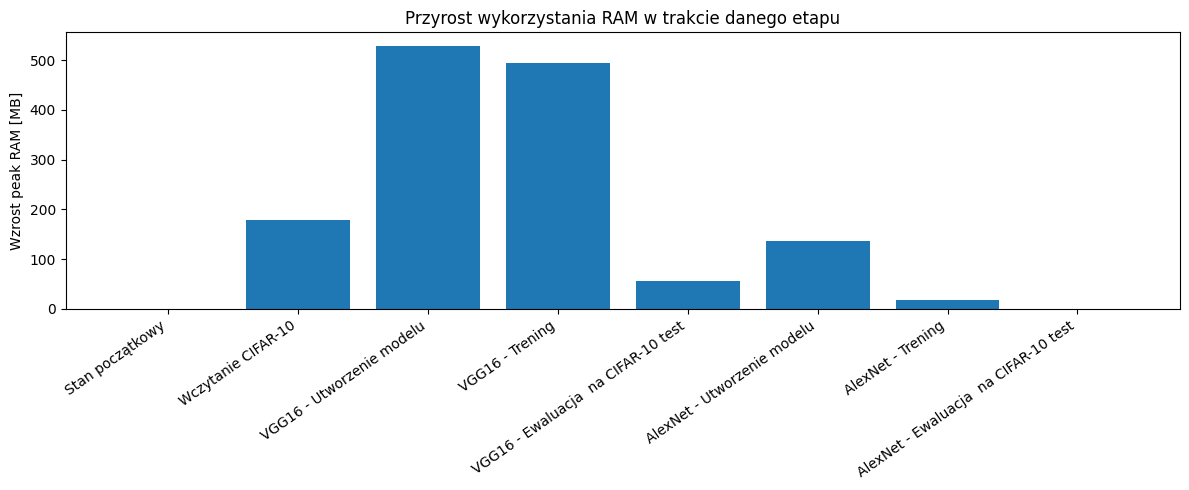

In [10]:
plot_df = memory_df.copy()
plot_df["label"] = plot_df.apply(
    lambda row: row["stage"] if pd.isna(row["model_type"]) else f"{row['model_type']} - {row['stage'].replace(row['model_type'], '').strip()}",
    axis=1,
)

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["ram_peak_increase_mb"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Wzrost peak RAM [MB]")
plt.title("Przyrost wykorzystania RAM w trakcie danego etapu")
plt.tight_layout()
plt.show()

## Wykres pamięci GPU


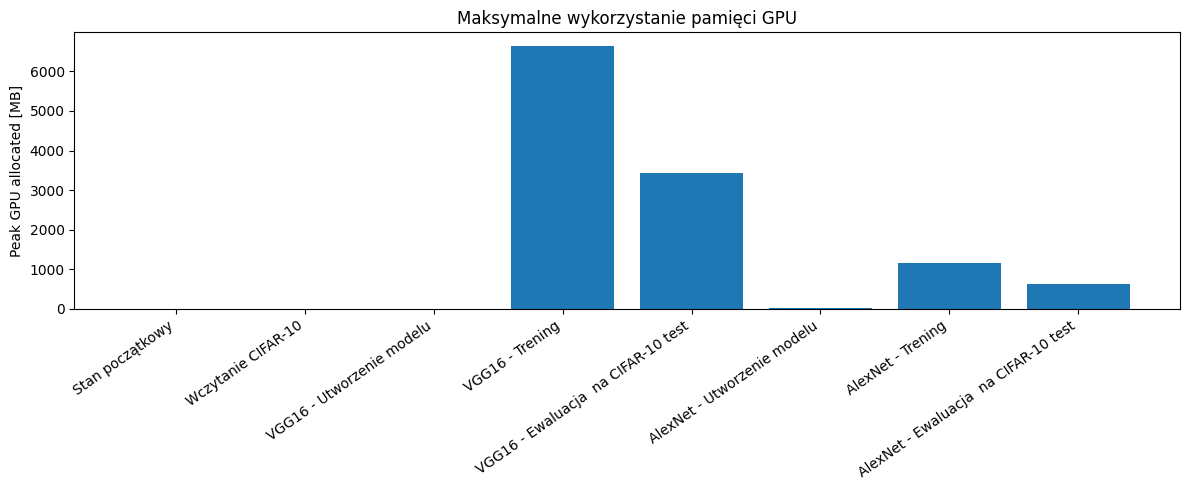

In [11]:
if memory_df["gpu_peak_allocated_mb"].notna().any():
    plt.figure(figsize=(12, 5))
    plt.bar(plot_df["label"], plot_df["gpu_peak_allocated_mb"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Peak GPU allocated [MB]")
    plt.title("Maksymalne wykorzystanie pamięci GPU")
    plt.tight_layout()
    plt.show()
else:
    print("CUDA nie jest dostępna albo nie wykryto pomiarów GPU.")

## Podsumowanie

W eksperymencie przeprowadzono analizę wykorzystania pamięci RAM przez modele VGG16 i AlexNet podczas pracy na zbiorze CIFAR-10. Pomiar wykonano dla kolejnych etapów: wczytania danych, utworzenia modelu, treningu oraz ewaluacji.

Dla każdego etapu zapisano pamięć przed rozpoczęciem operacji, pamięć po zakończeniu operacji oraz maksymalne zaobserwowane wykorzystanie pamięci w trakcie działania. Wyniki obu architektur znajdują się w jednej tabeli dzięki kolumnie `model_type`.